In [ ]:
import numpy as np
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
import seaborn as sns
%matplotlib inline

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/expenses (1).csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']= 14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']= '#00000000'


In [ ]:
df.age.describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


In [ ]:
fig =px.histogram(df,
             x='age',
             marginal='box',
             nbins=47,
             title='distribution of ages')
fig.update_layout(bargap=0.1)
fig.show()



In [ ]:
fig =px.histogram(df,
             x='bmi',
             marginal='box',
             color_discrete_sequence=['black'],
             title='distribution of BMI {body mass index}')
fig.update_layout(bargap=0.1)
fig.show()


In [ ]:
fig =px.histogram(df,
             x='charges',
             marginal='box',
              color='smoker',
             color_discrete_sequence=['red', 'green'],
             title='ANNUAL MADICAL CHARGES')
fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
fig =px.histogram(df,
             x='charges',
             marginal='box',
              color='sex',
             color_discrete_sequence=['red', 'green'],
             title='ANNUAL MADICAL CHARGES')
fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
fig =px.histogram(df,
             x='charges',
             marginal='box',
              color='region',
             color_discrete_sequence=['red', 'green'],
             title='ANNUAL MADICAL CHARGES')
fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [ ]:
px.histogram(df,
             x='smoker',
             color='sex',
             title='smoker')

In [ ]:
fig = px.scatter(df,
                 x='age',
                 y='charges',
                 color='smoker',
                 opacity=1,
                 hover_data=['sex'],
                 title='age vs charges')
fig.update_traces(marker_size=5)
fig.show()

In [ ]:
fig = px.scatter(df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 opacity=1,
                 hover_data=['sex'],
                 title='Bmi vs charges')
fig.update_traces(marker_size=5)
fig.show()

In [ ]:
px.violin(df,x='children',y='charges')

In [ ]:
df.charges.corr(df.age)

np.float64(0.2990081933306476)

In [ ]:
df.charges.corr(df.bmi)

np.float64(0.19834096883362895)

In [ ]:
df.charges.corr(df.children)

np.float64(0.06799822684790478)

In [ ]:
df.smoker

,smoker
0,yes
1,no
2,no
3,no
4,no
...,...
1333,no
1334,no
1335,no
1336,no


In [ ]:
smoker_values={'no':0,'yes':1}
smoker_numeric=df.smoker.map(smoker_values)
smoker_numeric

,smoker
0,1
1,0
2,0
3,0
4,0
...,...
1333,0
1334,0
1335,0
1336,0


In [ ]:
df.charges.corr(smoker_numeric)

np.float64(0.787251430498478)

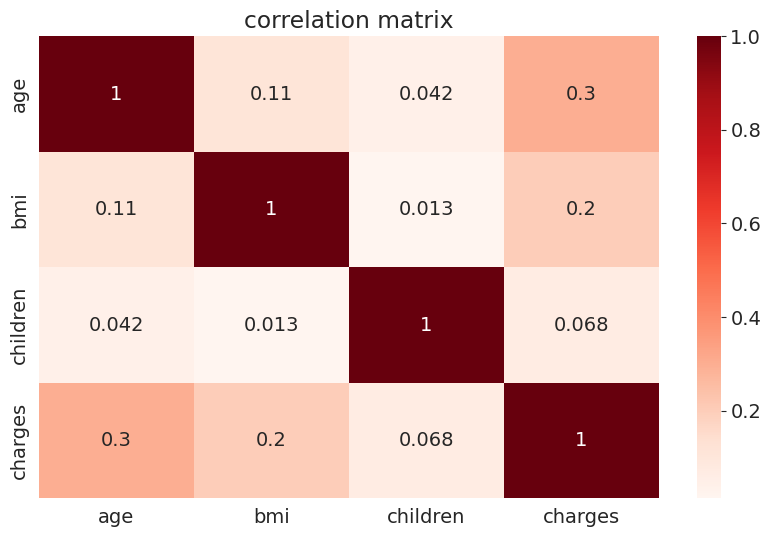

In [ ]:
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(),cmap='Reds',annot=True)
plt.title('correlation matrix');
plt.show()

In [ ]:
non_smoker_df=df[df.smoker=='no']

<Axes: title={'center': 'AGE VS CHARGES'}, xlabel='age', ylabel='charges'>

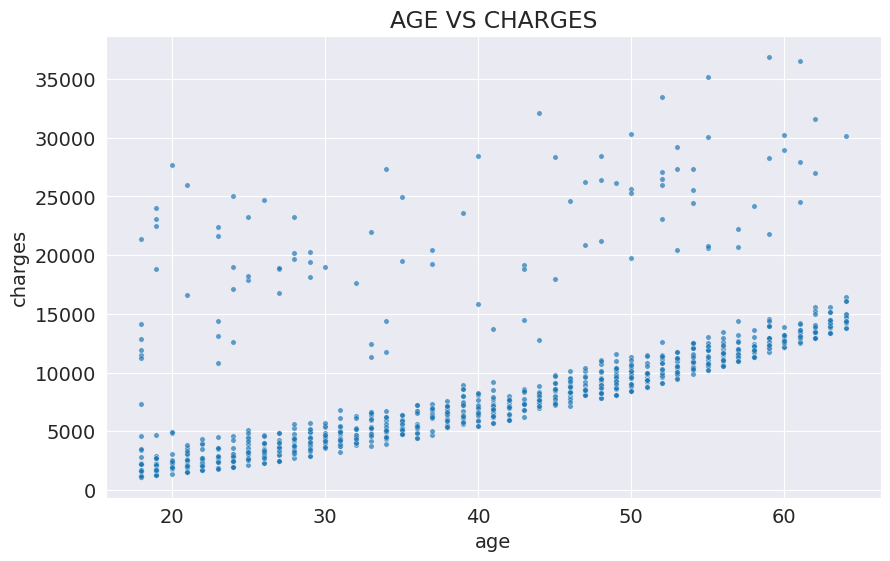

In [ ]:
plt.title('AGE VS CHARGES')
sns.scatterplot(data=non_smoker_df,x='age',y='charges',alpha=0.7,s=15)

In [ ]:
#y=a*x+b
#charges= a*charges+b a= parameter, b= weights

In [ ]:
def estimate_charges(age,a,b):
  return a*age+b

In [ ]:
a=50
b=100

In [ ]:
estimate_charges(80,a,b)

4100

In [ ]:
ages=non_smoker_df.age
ages

,age
1,18
2,28
3,33
4,32
5,31
...,...
1332,52
1333,50
1334,18
1335,18


In [ ]:
estimated_charges=estimate_charges(ages,a,b)
estimated_charges

,age
1,1000
2,1500
3,1750
4,1700
5,1650
...,...
1332,2700
1333,2600
1334,1000
1335,1000


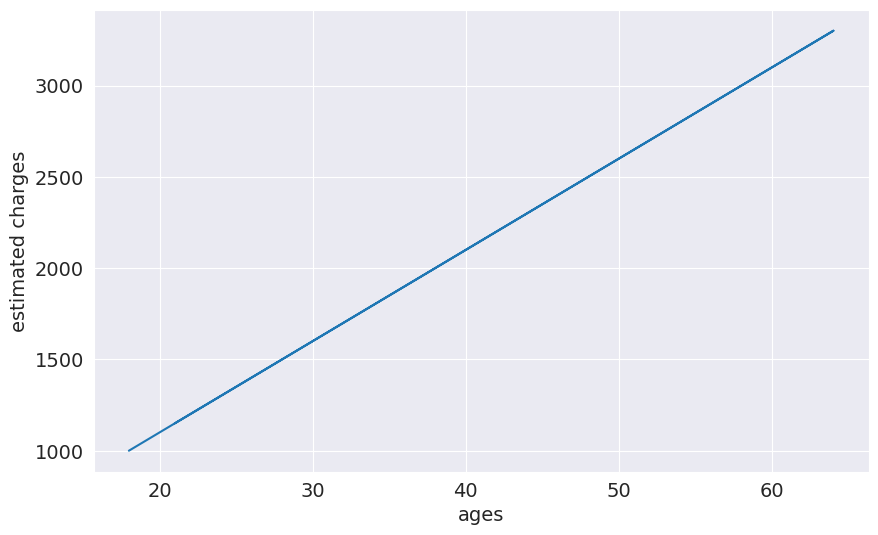

In [ ]:
plt.plot(ages,estimated_charges);
plt.xlabel('ages');
plt.ylabel('estimated charges');

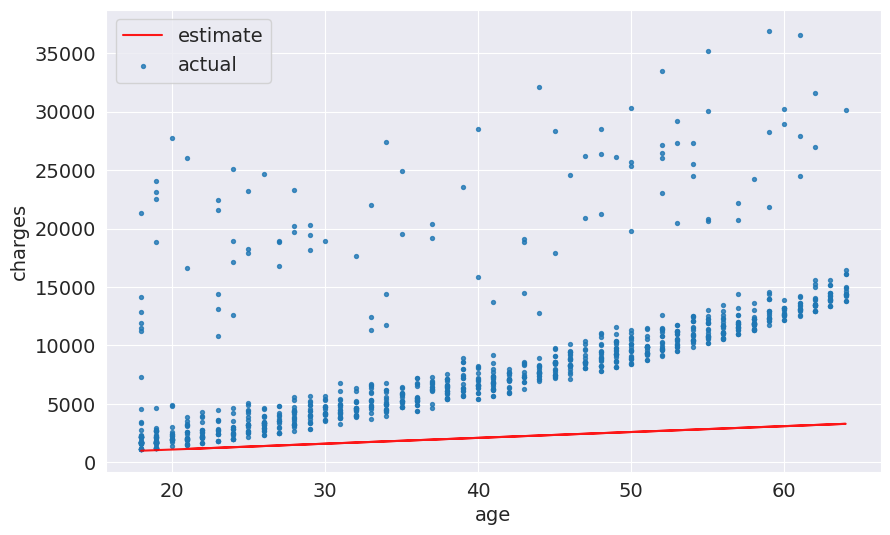

In [ ]:
target = non_smoker_df.charges
plt.plot(ages,estimated_charges,'r',alpha=0.9);
plt.scatter(ages,target,s=8,alpha=0.8);
plt.xlabel('age')
plt.ylabel('charges')
plt.legend(['estimate','actual']);


In [ ]:
def try_parameters(a, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    estimated_charges = estimate_charges(ages, a, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.8)
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('age')
    plt.ylabel('charges')
    plt.legend(['estimate', 'actual'])






In [ ]:
non_smoker_df = df[df.smoker == 'no']

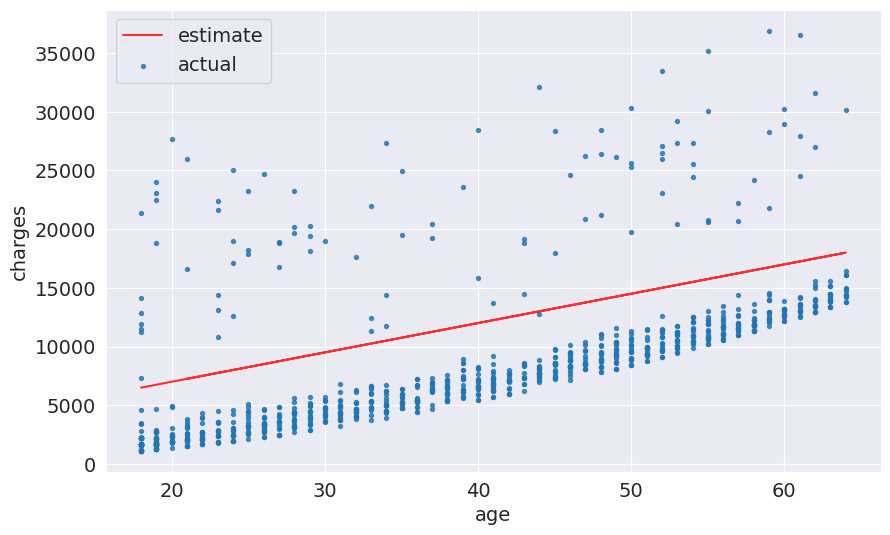

In [ ]:
 try_parameters(250,2000)


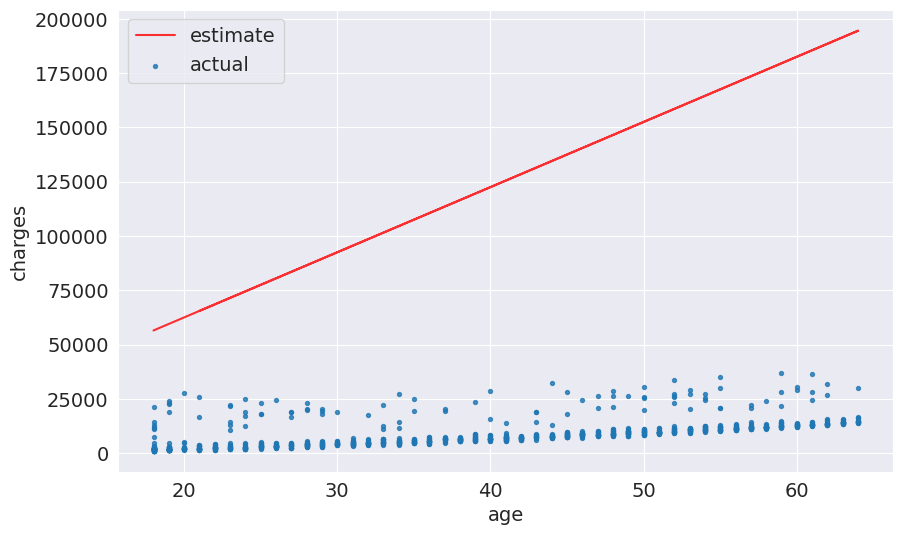

In [ ]:
 try_parameters(3000,2500)

In [ ]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [ ]:
a=200
b=200

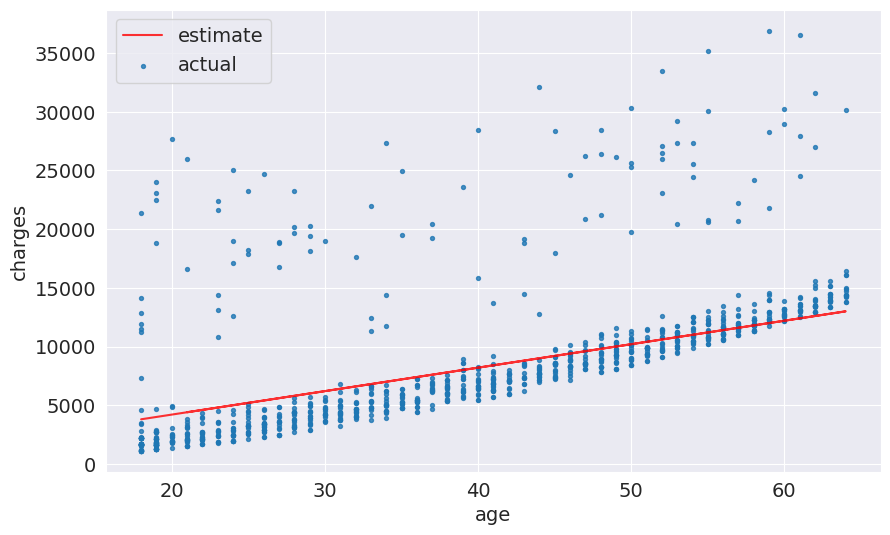

In [ ]:
try_parameters(a,b)

In [ ]:
targets=non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age,a,b)

In [ ]:
rmse(targets,predicted)

np.float64(4771.026760433572)

In [ ]:
inputs=non_smoker_df[['age']]
targets=non_smoker_df['charges']
print('inputs.shape:'),inputs.shape
print('targets.shape:'),targets.shape

inputs.shape:
targets.shape:


(None, (1064,))

In [ ]:
model = LinearRegression()
model.fit(inputs, targets)

LinearRegression()

In [ ]:
model.predict(np.array([[20],
              [35],
              [58]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 3253.55770006,  7262.29139253, 13409.01638764])

In [ ]:
predictions=model.predict(inputs)

In [ ]:
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [ ]:
targets

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


In [ ]:
rmse(targets,predictions)

np.float64(4662.505766636395)

In [ ]:
#a
model.coef_

array([267.24891283])

In [ ]:
#b
model.intercept_

np.float64(-2091.4205565650864)

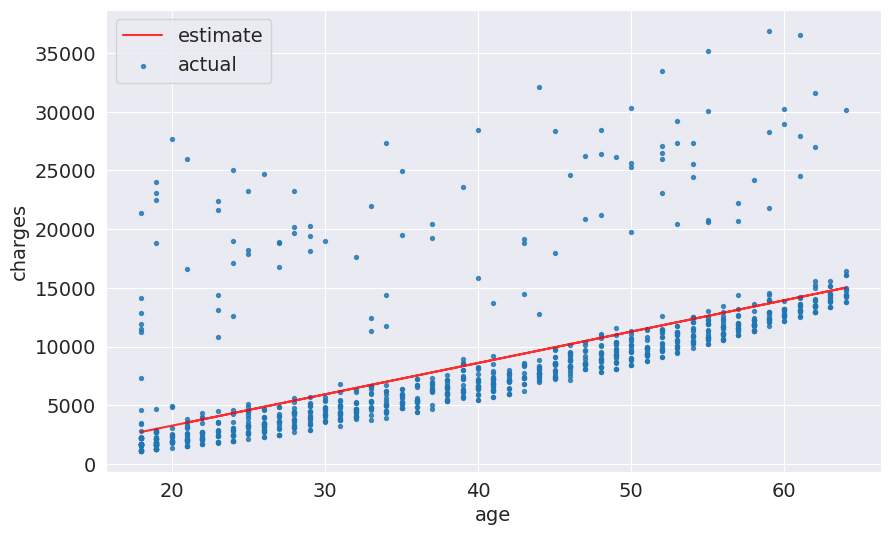

In [ ]:
try_parameters(model.coef_,model.intercept_)

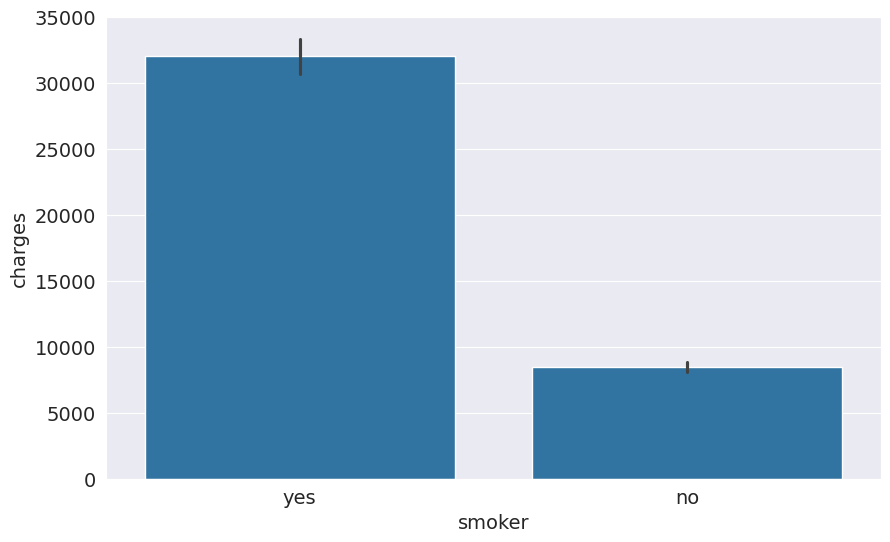

In [ ]:
sns.barplot(data=df,x='smoker',y='charges');

In [ ]:
smoker_codes= {'no':0,'yes':1}
df.smoker.map(smoker_codes)

,smoker
0,1
1,0
2,0
3,0
4,0
...,...
1333,0
1334,0
1335,0
1336,0


In [ ]:
smoker_code = {'yes': 1, 'no': 0}
df['smoker_code'] = df['smoker'].map(smoker_code)

In [ ]:
df.charges.corr(df.smoker_code)

np.float64(0.787251430498478)

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


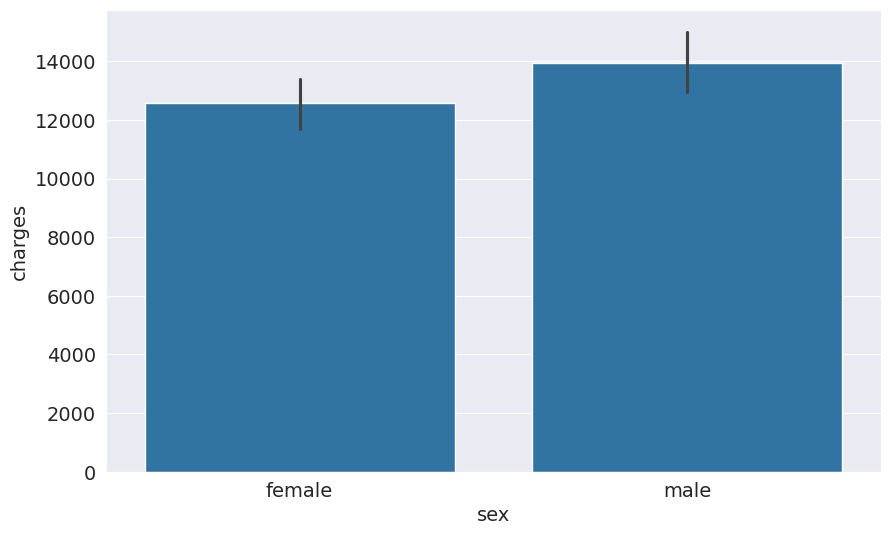

In [ ]:
sns.barplot(data=df,x='sex',y='charges');

In [ ]:
sex_codes= {'female':0,'male':1}


In [ ]:
sex_code = {'male': 1, 'female': 0}
df['sex_code'] = df['sex'].map(sex_code)

In [ ]:
df.charges.corr(df.sex_code)

np.float64(0.057292062202025484)

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


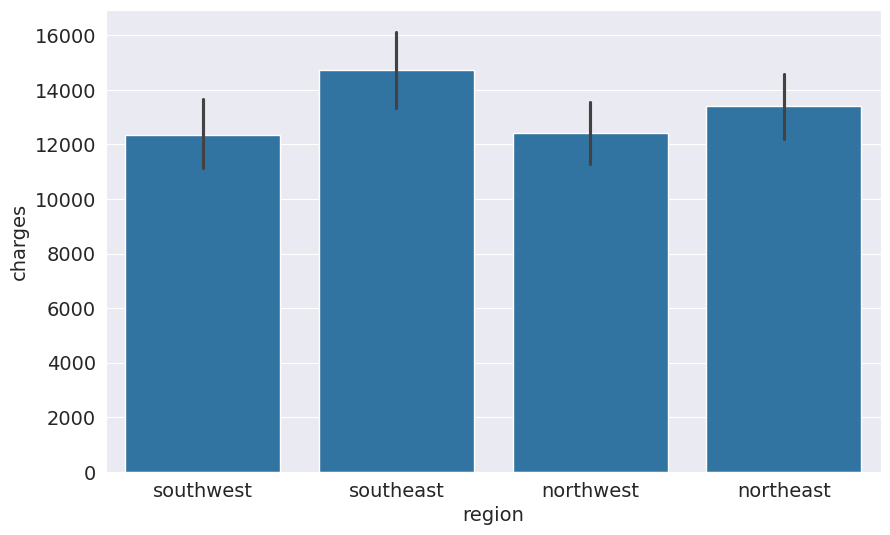

In [ ]:
sns.barplot(data=df,x='region',y='charges');

In [ ]:
from sklearn import preprocessing
enc=preprocessing.OneHotEncoder()
enc.fit(df[['region']])
enc.categories_


[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [ ]:
enc.transform([['northeast'],['northwest']]).toarray()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but OneHotEncoder was fitted with feature names



array([[1., 0., 0., 0.],
       [0., 1., 0., 0.]])

In [ ]:
df[['region']]

,region
0,southwest
1,southeast
2,southeast
3,northwest
4,northwest
...,...
1333,northwest
1334,northeast
1335,southeast
1336,southwest


In [ ]:
one_hot=enc.transform(df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [ ]:
df[['northeast','northwest','southeast','southwest']]=one_hot

In [ ]:
df


,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [ ]:
# Create inputs and targets
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = df[input_cols], df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
numeric_cols=['age','bmi','children']
scaler=StandardScaler()
scaler.fit(df[numeric_cols])

StandardScaler()

In [ ]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [ ]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [ ]:
df[numeric_cols]

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0
...,...,...,...
1333,50,30.970,3
1334,18,31.920,0
1335,18,36.850,0
1336,21,25.800,0


In [ ]:
scaled_inputs=scaler.transform(df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [ ]:
df[input_cols].loc[10]

,10
age,25.00
bmi,26.22
children,0.00
smoker_code,0.00
sex_code,1.00
northeast,1.00
northwest,0.00
southeast,0.00
southwest,0.00


In [ ]:
model.predict([[28,30, 2,1,0,0,1,0,0.]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([29875.81463599])